# Data Analysis

=== PeMS DATA ANALYSIS ===
Shape: (1501, 3)
Columns: ['from', 'to', 'cost']

Sample data:
   from   to   cost
0    73    5  352.6
1     5  154  347.2
2   154  263  392.9
3   263   56  440.8
4    56   96  374.6

📊 Descriptive statistics:
              from           to         cost
count  1501.000000  1501.000000  1501.000000
mean    305.879414   303.468354   155.867951
std     257.442896   256.217595   240.138476
min       0.000000     0.000000     0.032000
25%      97.000000    95.000000     0.809000
50%     217.000000   215.000000     2.252000
75%     505.000000   498.000000   335.700000
max     882.000000   882.000000  3274.400000

🔍 Missing values:
from    0
to      0
cost    0
dtype: int64

📈 Road network analysis:
Number of nodes (sensors): 883
Number of edges (roads): 1477
Graph density: 0.0038


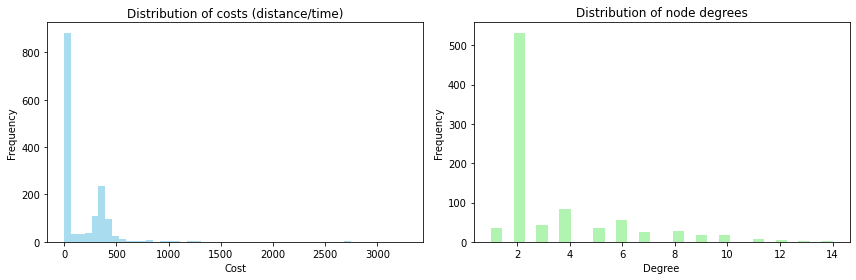

=== NYC TAXI DATA ANALYSIS ===
Shape: (228745, 11)
Columns: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']

Sample data:
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3         

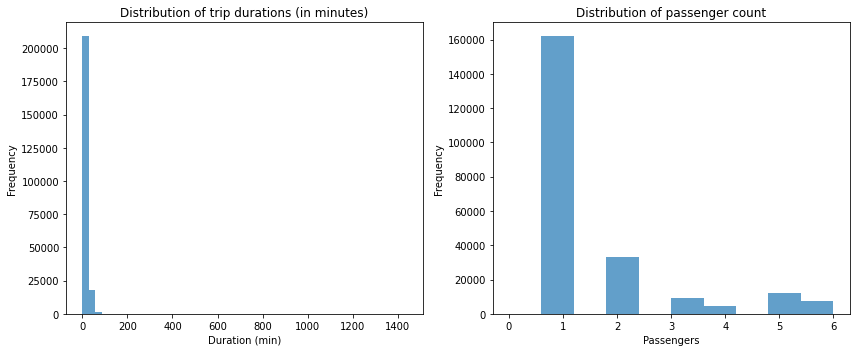


=== FEATURE ENGINEERING for PeMS ===
Columns found: ['from', 'to', 'cost']
Nodes: 883
Edges: 1477
Graph density: 0.0038

Preview with added features:
   from   to   cost  from_degree  to_degree  from_centrality  to_centrality
0    73    5  352.6            5          7         0.006903       0.010151
1     5  154  347.2            7          8         0.010151       0.013020
2   154  263  392.9            8          4         0.013020       0.004067
3   263   56  440.8            4          6         0.004067       0.008989
4    56   96  374.6            6          7         0.008989       0.013302

=== FEATURE ENGINEERING for NYC Taxi ===

Preview with added features:
   distance_km  hour  weekday  month  is_weekend  trip_duration_min
0     1.498521    17        0      3           0           7.583333
1     1.805507     0        6      6           1          11.050000
2     6.385098    11        1      1           0          35.400000
3     1.485498    19        2      4           0 

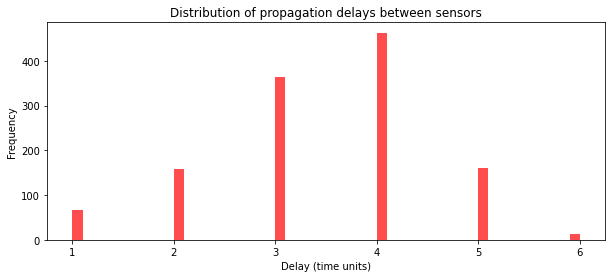

Average propagation delay: 3.43
Maximum propagation delay: 6.00

=== DATASET INTEGRATION ===
Integration completed — datasets ready for combined analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

def analyze_pems_data():
    print("=== PeMS DATA ANALYSIS ===")
    
    # Load datasets
    df_pems04 = pd.read_csv('PEMS04.csv')
    df_pems07 = pd.read_csv('PEMS07.csv')
    df_pems08 = pd.read_csv('PEMS08.csv')
    
    # Merge datasets into one
    df_pems = pd.concat([df_pems04, df_pems07, df_pems08], ignore_index=True)
    print(f"Shape: {df_pems.shape}")
    print(f"Columns: {df_pems.columns.tolist()}")
    
    # Display sample rows from dataset
    print("\nSample data:")
    print(df_pems.head())
    
    # Descriptive statistics
    print("\n📊 Descriptive statistics:")
    print(df_pems.describe())
    
    # Missing value analysis
    print("\n🔍 Missing values:")
    print(df_pems.isnull().sum())
    
    # Network graph construction (road network)
    # Each row defines a connection between sensors
    G = nx.Graph()
    for _, row in df_pems.iterrows():
        G.add_edge(row['from'], row['to'], weight=row['cost'])
    
    print(f"\n📈 Road network analysis:")
    print(f"Number of nodes (sensors): {G.number_of_nodes()}")
    print(f"Number of edges (roads): {G.number_of_edges()}")
    print(f"Graph density: {nx.density(G):.4f}")
    
    # Basic visualization for costs and node degrees
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(df_pems['cost'], bins=50, alpha=0.7, color='skyblue')
    plt.title('Distribution of costs (distance/time)')
    plt.xlabel('Cost')
    plt.ylabel('Frequency')
    
    plt.subplot(1, 2, 2)
    degrees = [d for n, d in G.degree()]
    plt.hist(degrees, bins=30, alpha=0.7, color='lightgreen')
    plt.title('Distribution of node degrees')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    return df_pems, G

def analyze_nyctaxi_data():
    print("=== NYC TAXI DATA ANALYSIS ===")

    # Load NYC taxi dataset
    df_taxi = pd.read_csv("NYC_taxi.csv")
    print(f"Shape: {df_taxi.shape}")
    print(f"Columns: {df_taxi.columns.tolist()}")

    # Display preview
    print("\nSample data:")
    print(df_taxi.head())

    # Convert time columns to datetime
    df_taxi['pickup_datetime'] = pd.to_datetime(df_taxi['pickup_datetime'])
    df_taxi['dropoff_datetime'] = pd.to_datetime(df_taxi['dropoff_datetime'])

    # Descriptive statistics
    print("\n📊 Descriptive statistics:")
    print(df_taxi.describe())

    # Missing values
    print("\n🔍 Missing values:")
    print(df_taxi.isnull().sum())

    # Compute trip duration in minutes using pickup/dropoff times
    df_taxi['computed_trip_duration'] = (
        df_taxi['dropoff_datetime'] - df_taxi['pickup_datetime']
    ).dt.total_seconds() / 60

    # Validate duration consistency with existing provided duration
    df_taxi['absolute_diff'] = abs(
        df_taxi['trip_duration'] - df_taxi['computed_trip_duration'] * 60
    )

    print("\n⏱ Trip duration consistency check:")
    print(f"Average duration (file): {df_taxi['trip_duration'].mean():.2f} sec")
    print(f"Average duration (computed): {df_taxi['computed_trip_duration'].mean():.2f} min")
    print(f"Mean absolute error: {df_taxi['absolute_diff'].mean():.2f} sec")

    # Visualizations
    plt.figure(figsize=(12, 5))

    # Trip duration distribution
    plt.subplot(1, 2, 1)
    plt.hist(df_taxi["trip_duration"] / 60, bins=50, alpha=0.7)
    plt.title("Distribution of trip durations (in minutes)")
    plt.xlabel("Duration (min)")
    plt.ylabel("Frequency")

    # Passenger count distribution
    plt.subplot(1, 2, 2)
    plt.hist(df_taxi["passenger_count"], bins=10, alpha=0.7)
    plt.title("Distribution of passenger count")
    plt.xlabel("Passengers")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    return df_taxi

def prepare_pems_features(df_pems):
    print("\n=== FEATURE ENGINEERING for PeMS ===")

    # Display available columns
    print("Columns found:", df_pems.columns.tolist())

    required_columns = ['from', 'to', 'cost']
    # Check required columns exist
    for col in required_columns:
        if col not in df_pems.columns:
            raise ValueError(f" Missing column: {col}")

    # Build graph from dataset
    G = nx.Graph()
    for _, row in df_pems.iterrows():
        G.add_edge(row['from'], row['to'], weight=row['cost'])

    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    print(f"Graph density: {nx.density(G):.4f}")

    # Node features: Degree
    degrees = dict(G.degree())
    df_pems['from_degree'] = df_pems['from'].map(degrees)
    df_pems['to_degree'] = df_pems['to'].map(degrees)

    # Node features: Betweenness centrality
    centrality = nx.betweenness_centrality(G)
    df_pems['from_centrality'] = df_pems['from'].map(centrality)
    df_pems['to_centrality'] = df_pems['to'].map(centrality)

    print("\nPreview with added features:")
    print(df_pems.head())

    return df_pems, G

def prepare_nyctaxi_features(df_taxi):
    print("\n=== FEATURE ENGINEERING for NYC Taxi ===")

    # Haversine distance (geographical distance between pickup and dropoff)
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371  # Earth radius (km)
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return R * c

    df_taxi['distance_km'] = haversine(
        df_taxi['pickup_latitude'],
        df_taxi['pickup_longitude'],
        df_taxi['dropoff_latitude'],
        df_taxi['dropoff_longitude']
    )

    # Convert time
    df_taxi['pickup_datetime'] = pd.to_datetime(df_taxi['pickup_datetime'])

    # Temporal features
    df_taxi['hour'] = df_taxi['pickup_datetime'].dt.hour
    df_taxi['weekday'] = df_taxi['pickup_datetime'].dt.weekday
    df_taxi['month'] = df_taxi['pickup_datetime'].dt.month
    df_taxi['is_weekend'] = df_taxi['weekday'].isin([5, 6]).astype(int)

    # Target variable in minutes
    df_taxi['trip_duration_min'] = df_taxi['trip_duration'] / 60

    print("\nPreview with added features:")
    print(df_taxi[['distance_km', 'hour', 'weekday', 'month', 'is_weekend', 'trip_duration_min']].head())

    return df_taxi

def analyze_propagation_delays(df_pems, G):
    print("=== PROPAGATION DELAY ANALYSIS ===")
    
    # Compute shortest paths between a subset of nodes for performance
    propagation_delays = []
    for i, node1 in enumerate(list(G.nodes())[:50]):
        for j, node2 in enumerate(list(G.nodes())[:50]):
            if i < j:
                try:
                    delay = nx.shortest_path_length(G, node1, node2, weight='cost')
                    propagation_delays.append(delay)
                except:
                    continue
    
    plt.figure(figsize=(10, 4))
    plt.hist(propagation_delays, bins=50, alpha=0.7, color='red')
    plt.title('Distribution of propagation delays between sensors')
    plt.xlabel('Delay (time units)')
    plt.ylabel('Frequency')
    plt.show()
    
    print(f"Average propagation delay: {np.mean(propagation_delays):.2f}")
    print(f"Maximum propagation delay: {np.max(propagation_delays):.2f}")
    
    return propagation_delays

def integrate_datasets(df_pems, df_taxi):
    print("\n=== DATASET INTEGRATION ===")
    
    df_pems_integrated = df_pems.copy()
    df_taxi_integrated = df_taxi.copy()
    
    # Add indicator to identify dataset origin
    df_pems_integrated['data_source'] = 'PeMS'
    df_taxi_integrated['data_source'] = 'NYC_Taxi'
    
    # Temporal alignment
    if 'pickup_datetime' in df_taxi_integrated.columns:
        df_taxi_integrated['timestamp'] = pd.to_datetime(df_taxi_integrated['pickup_datetime'])
    else:
        # Create dummy timestamps for PeMS if not available
        df_pems_integrated['timestamp'] = pd.date_range(start='2023-01-01', periods=len(df_pems), freq='H')
    
    print("Integration completed — datasets ready for combined analysis")
    return df_pems_integrated, df_taxi_integrated


df_pems, G = analyze_pems_data()
df_taxi = analyze_nyctaxi_data()
df_pems, G = prepare_pems_features(df_pems)
df_taxi = prepare_nyctaxi_features(df_taxi)
propagation_delays = analyze_propagation_delays(df_pems, G)
df_pems_integrated, df_taxi_integrated = integrate_datasets(df_pems, df_taxi)
